In [117]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd
import scipy.stats as st
import itertools
from matplotlib import gridspec
from tqdm import tqdm

from joblib import Parallel, delayed

import sys
sys.path.append('../../python/6_CRM')
from CRM import CRM
from CRM_utils import has_converged


sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [118]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'cs_sweep'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


run = '20251219-000823'
# run = '20260129-111722'
# run = '20260614-003620'
run = '20260615-221352'

fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)


run_simulations = True

In [119]:
parsed_data = []

n_cs_arr = data['cs_arr'] 
K_std_arr = data['Kstd_arr'] 
csp_arr = data['csp_arr']
for i in range(args.N):
    N = data[f'N_final_{i}']
    C = data[f'C_{i}']
    n_cs = n_cs_arr[i]
    K_std = K_std_arr[i]
    csp = csp_arr[i]
    
    for j in range(args.iterations):
        richness = np.sum(N[:, j] > 1e-6)
        abundance = list(N[:, j])
        parsed_data.append([i, j, n_cs, K_std, csp, richness]+ abundance)

In [120]:
df = pd.DataFrame(parsed_data, columns = ['i', 'cs_j', 'n_cs', 'K_std', 'csp', 'richness', 'N1', 'N2', 'N3', 'N4'])


In [121]:
df.shape

(700000, 10)

# Identify communities with high and low average richness

In [122]:
mean_richness = df.groupby('i')['richness'].mean()

In [123]:
Ni = df.i.max()+1

In [124]:
bottom_10 = mean_richness.sort_values().index[:Ni//10]
rich_10 = mean_richness.sort_values().index[-Ni//10:]

In [125]:
C_bottom = []
C_rich = []

for i in bottom_10:
    C_bottom.append(data[f'C_{i}'])
for i in rich_10:
    C_rich.append(data[f'C_{i}'])

# Niche overlap

In [126]:
def mean_niche_overlap(C):
    """
    Compute the average niche overlap between species in a community.
    Mean of each pair (divide by union)
    """
    overlaps = []
    S = C.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ci = C[i, :]
        cj = C[j, :]
        overlaps_ij = np.sum((ci*cj).astype(bool))/np.sum((ci+cj).astype(bool))
        overlaps.append(overlaps_ij)
    return np.mean(overlaps)

def niche_overlap(C):
    """Compute the average niche overlap between species in a community."""
    overlaps = []
    S = C.shape[0]
    Cb = C.astype(bool)
    for i, j in itertools.permutations(range(S), 2):
        ci = Cb[i, :]
        cj = Cb[j, :]
        overlaps_ij = np.sum(ci*cj)/np.sum(ci)
        overlaps.append(overlaps_ij)
    return np.mean(overlaps)

In [127]:
noi_bottom = []
noi_rich = []
for C in C_bottom:
    noi_bottom.append(niche_overlap(C))
for C in C_rich:
    noi_rich.append(niche_overlap(C))


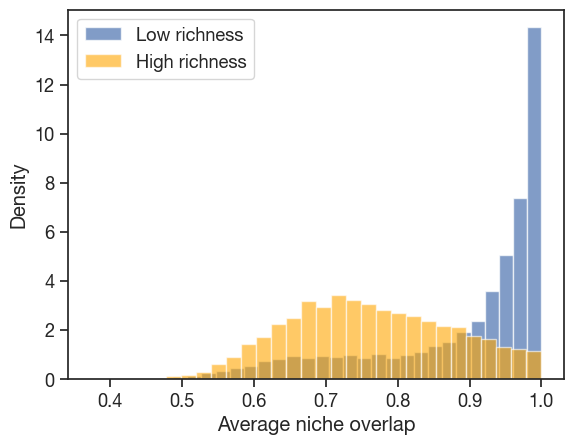

In [128]:
plt.hist(noi_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(noi_rich, bins=30, alpha=0.6, label='High richness', color='orange', density=True)
plt.xlabel('Average niche overlap')
plt.ylabel('Density')
plt.legend()

In [129]:
# Euclidean distance in consumption space
def euclidean_distance_C(C):
    """Compute the average Euclidean distance between species in consumption space."""
    distances = []
    S = C.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ci = C[i, :]
        cj = C[j, :]
        dist_ij = np.linalg.norm(ci - cj)
        distances.append(dist_ij)
    return np.mean(distances)

In [130]:
edc_bottom = []
edc_rich = []
for C in C_bottom:
    edc_bottom.append(euclidean_distance_C(C))
for C in C_rich:
    edc_rich.append(euclidean_distance_C(C))



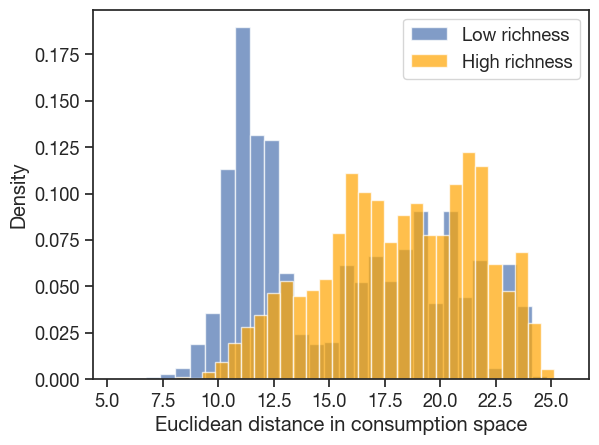

In [131]:
plt.hist(edc_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(edc_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in consumption space')
plt.ylabel('Density')
plt.legend()

# Private niches


In [132]:
(C.astype(bool).sum(axis = 0) == 1).sum()

np.int64(2)

In [133]:
def private_niches(C, fraction=True):
    """Compute the fraction of private niches in a community."""
    if fraction:
        return (C.astype(bool).sum(axis = 0) == 1).sum() / C.shape[1]
    else:
        return (C.astype(bool).sum(axis = 0) == 1).sum()

In [134]:
pn_bottom = []
pn_rich = []
for C in C_bottom:
    pn_bottom.append(private_niches(C, fraction=True))
for C in C_rich:
    pn_rich.append(private_niches(C, fraction=True))

Text(0, 0.5, 'Density')

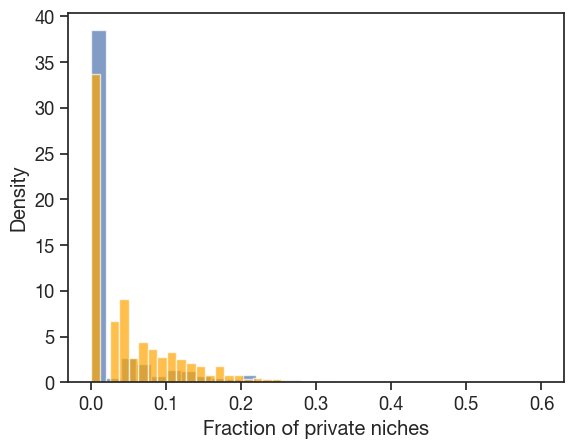

In [135]:
plt.hist(pn_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(pn_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Fraction of private niches')
plt.ylabel('Density')

# Average Km distance

In [136]:
def K_log_eucledian_distance(K):
    distances = []
    S = K.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ki = np.log10(K[i, :])
        kj = np.log10(K[j, :])
        dist_ij = np.linalg.norm(ki - kj)
        distances.append(dist_ij)
    return np.mean(distances)


In [137]:
# for key in data.keys():
#     print(key)


In [138]:
ked_bottom = []
ked_rich = []
for i in bottom_10:
    K = data[f'K_{i}']
    ked_bottom.append(K_log_eucledian_distance(K))
for i in rich_10:
    K = data[f'K_{i}']
    ked_rich.append(K_log_eucledian_distance(K))

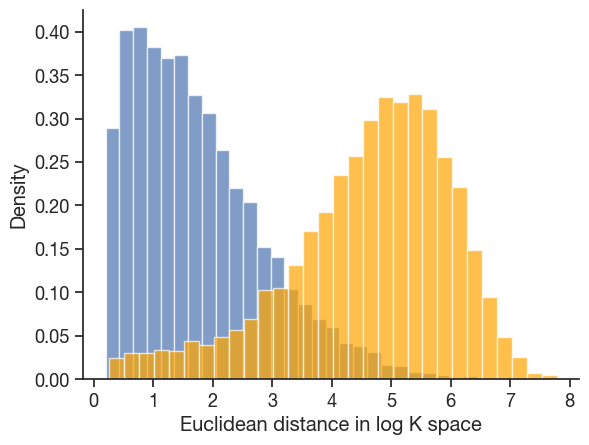

In [139]:
plt.hist(ked_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(ked_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in log K space')
plt.ylabel('Density')
sns.despine()

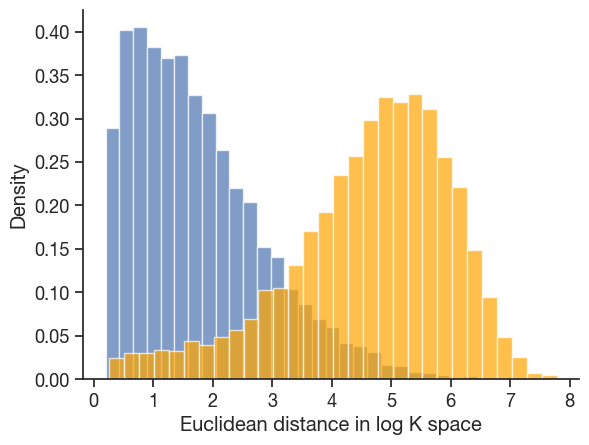

In [140]:
plt.hist(ked_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(ked_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in log K space')
plt.ylabel('Density')
sns.despine()

# Log K distance and niche overlap

In [141]:
len(list(bottom_10) + list(rich_10))

20000

In [142]:
plot_df = pd.DataFrame(index = list(bottom_10) + list(rich_10))
plot_df['richness'] = list(mean_richness.loc[bottom_10]) + list(mean_richness.loc[rich_10])
plot_df['noi'] = noi_bottom + noi_rich
plot_df['edc'] = edc_bottom + edc_rich
plot_df['ked'] = ked_bottom + ked_rich
plot_df['Category'] = ['Bottom 10% richness']*len(bottom_10) + ['Top 10% richness']*len(rich_10)


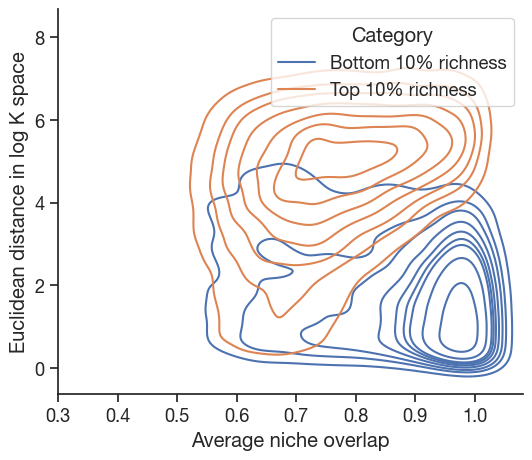

In [143]:
fig, ax = plt.subplots(figsize=(6,5))
sns.kdeplot(data=plot_df, x='noi', y = 'ked', hue = 'Category')
plt.xlabel('Average niche overlap')
plt.ylabel('Euclidean distance in log K space')
sns.despine()

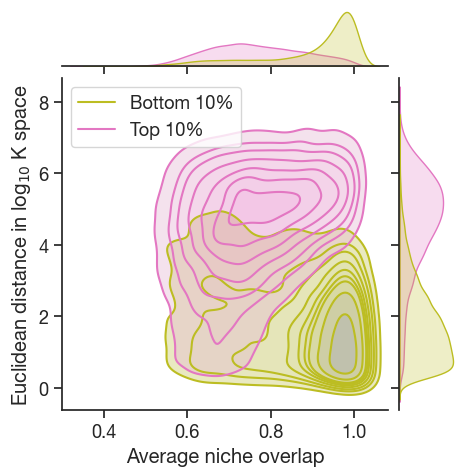

In [144]:
palette = sns.color_palette("tab10", n_colors=10)
palette2 = [palette[8], palette[6]]
g = sns.jointplot(data=plot_df, x='noi', y='ked', hue='Category', kind='kde', height=5, palette = palette2, fill = True, alpha = 0.4)#, cut = 0)
sns.kdeplot(data=plot_df, x='noi', y = 'ked', hue = 'Category', ax = g.ax_joint, palette = palette2, fill = False, alpha = 1)
g.ax_joint.set_xlabel('Average niche overlap')
g.ax_joint.set_ylabel(r'Euclidean distance in log$_{10}$ K space')
sns.move_legend(g.ax_joint, "upper left", bbox_to_anchor=(0, 1), title='')
# g.ax_joint.set_xlim(.4,1)
# g.ax_joint.set_ylim(0, 8)

# Change legende labels
new_labels = ['Bottom 10%', 'Top 10%']
for t, l in zip(g.ax_joint.get_legend().texts, new_labels):
    t.set_text(l) 

plt.savefig(figure_folder / 'community_properties_noi_ked.pdf', dpi=300, bbox_inches='tight')

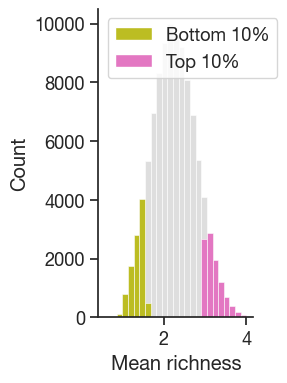

In [145]:
fig, ax = plt.subplots(figsize=(2,4))

# Calculate bin edges first
bin_edges = np.histogram_bin_edges(mean_richness, bins=25)
g = sns.histplot(mean_richness, ax = ax, bins = bin_edges, color = 'lightgray')
sns.histplot(data=plot_df, x='richness', hue='Category', palette = palette2, ax = ax, bins = bin_edges, alpha = 1)
sns.despine()
sns.move_legend(ax, "upper left", bbox_to_anchor=(0, 1), title='', ncol=1)
# Change legende labels
new_labels = ['Bottom 10%', 'Top 10%']
for t, l in zip(ax.get_legend().texts, new_labels):
    t.set_text(l) 
plt.xlabel('Mean richness')
plt.savefig(figure_folder / 'richness_hist.pdf', dpi=300, bbox_inches='tight')

# C/K ratio

In [146]:
def CK_euclidean_distance(CK_ratio):
    distances = []
    S = CK_ratio.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        cki = np.log10(CK_ratio[i, :])
        ckj = np.log10(CK_ratio[j, :])
        # Replace inf with a small number
        cki = np.where(np.isinf(cki), -3, cki)
        ckj = np.where(np.isinf(ckj), -3, ckj)
        
        dist_ij = np.linalg.norm(cki - ckj)
        distances.append(dist_ij)
    return np.mean(distances)

In [147]:
np.log10(0)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_38592/135924841.py:1: RuntimeWarning: divide by zero encountered in log10
  np.log10(0)


np.float64(-inf)

In [148]:
# Perform cell-by-cell division of C on K
ckd_bottom = []
for i in bottom_10:
    C = data[f'C_{i}']
    K = data[f'K_{i}']
    CK_ratio = C / K
    ckd_bottom.append(CK_euclidean_distance(CK_ratio))
ckd_rich = []
for i in rich_10:
    C = data[f'C_{i}']
    K = data[f'K_{i}']
    CK_ratio = C / K
    ckd_rich.append(CK_euclidean_distance(CK_ratio))

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_38592/1167146942.py:5: RuntimeWarning: divide by zero encountered in log10
  cki = np.log10(CK_ratio[i, :])
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_38592/1167146942.py:6: RuntimeWarning: divide by zero encountered in log10
  ckj = np.log10(CK_ratio[j, :])


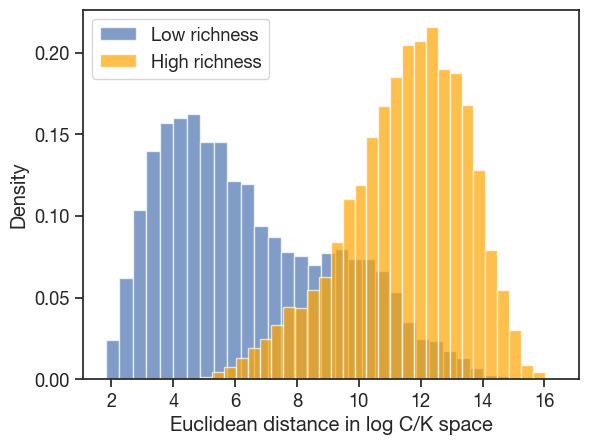

In [149]:
plt.hist(ckd_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(ckd_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in log C/K space')
plt.ylabel('Density')
plt.legend()

In [150]:
df_mean = df.groupby('i').agg({'richness':('mean', 'std')}).reset_index()

In [151]:
df_mean.columns = ['i', 'richness_mean', 'richness_std']

In [152]:
noi_data = []
for i in df_mean['i']:
    noi_data.append(niche_overlap(data[f'C_{i}']))
df_mean['noi'] = noi_data

Text(0, 0.5, 'Average niche overlap')

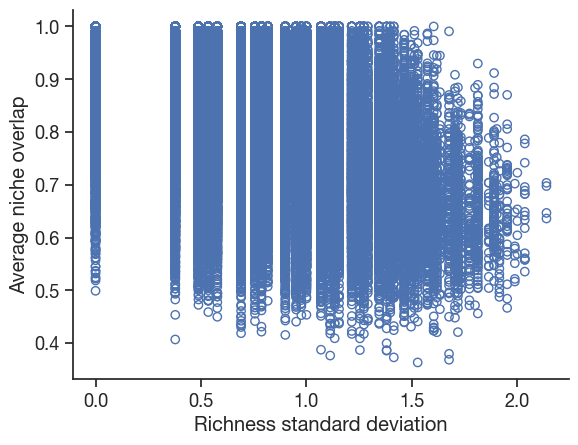

In [153]:
plt.scatter(df_mean['richness_std'], df_mean['noi'], marker = 'o', facecolor='none', edgecolor='b')
sns.despine()
plt.xlabel('Richness standard deviation')
plt.ylabel('Average niche overlap')

In [154]:
st.pearsonr(df_mean['richness_std'], df_mean['noi'])

PearsonRResult(statistic=np.float64(-0.4085112714038501), pvalue=np.float64(0.0))

# Monoculture experiments

In [155]:
indices = list(bottom_10) + list(rich_10)

In [156]:

def run_single_monoculture(i, j, k, C, D, K, n_cs, leakage, max_time, initial_abundance, initial_c_conc, dt, method):
    """Run a single monoculture simulation"""
    # if C[k, j] < 1e-6:
    #     return None
    
    N0 = np.ones(1) * initial_abundance
    R0 = np.zeros(n_cs)
    R0[j] = initial_c_conc
    l = leakage * np.ones(1)
    
    c = CRM(1, n_cs, C=C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
    
    try:
        sol = c.run(max_time, N0.copy(), R0.copy(), dt=dt, method=method, max_calls=1e5)
        N = c.N[-1, :]
        R = c.R[-1, :]
        return {'final_abundance': N, 'final_resources': R, 'species_no': k, 'i': i, 'j': j}
    except (RuntimeError, ValueError):
        print('Error: ', i, k)
        return {'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j': j}

initial_abundance = 1e-5
if run_simulations:
    max_time = 200
    
    dt = 1
    method = 'LSODA'
    initial_c_conc = 10
    iterations = 8
    
    # Prepare all simulation parameters
    sim_params = []
    for i in indices:
        n_cs = df.loc[df.i==i, 'n_cs'].values[0]
        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        
        for j in range(iterations):
            for k in range(4):
                sim_params.append((i, j, k, C, D, K, n_cs, args.leakage, max_time, 
                                 initial_abundance, initial_c_conc, dt, method))
    
    # Run in parallel
    m_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_monoculture)(*params) for params in sim_params
    )
    
    # Filter out None results
    monoculture_data = [r for r in m_results if r is not None]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1895333134351004s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.02869105339050293s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.022570133209228516s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.11179995536804199s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 164 tasks      

Error:  61650 3


[Parallel(n_jobs=-1)]: Done 323144 tasks      | elapsed: 27.5min
[Parallel(n_jobs=-1)]: Done 325152 tasks      | elapsed: 27.7min
[Parallel(n_jobs=-1)]: Done 327176 tasks      | elapsed: 27.9min
[Parallel(n_jobs=-1)]: Done 329200 tasks      | elapsed: 28.1min
[Parallel(n_jobs=-1)]: Done 331240 tasks      | elapsed: 28.4min
[Parallel(n_jobs=-1)]: Done 333280 tasks      | elapsed: 28.6min
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


Error:  18091 3


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
[Parallel(n_jobs=-1)]: Batch computation too slow (2.015075483419934s.) Setting batch_size=1.


...

[Parallel(n_jobs=-1)]: Done 638056 tasks      | elapsed: 62.9min
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


Error:  27465 2


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


Error:  34582 2


[Parallel(n_jobs=-1)]: Done 639868 tasks      | elapsed: 63.1min
[Parallel(n_jobs=-1)]: Done 639985 out of 640000 | elapsed: 63.1min remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 640000 out of 640000 | elapsed: 63.1min finished


In [157]:
fn_mono = results_folder / f'{run}_monocultures.npz'

if run_simulations:
    with open(fn_mono, 'wb') as f:
        np.savez(f, monoculture_data)
else:
    with open(fn_mono, 'rb') as f:
        monoculture_data = np.load(f, allow_pickle=True)['arr_0']

# Spent medium cultivations

In [158]:
def run_single_spent_medium(i, j, k_spent,n_cs, R0, C, D, K, leakage, max_time, initial_abundance, dt, method):
    """Run a single spent medium simulation"""    

    l = leakage * np.ones(1)
    N0 = np.ones(1) * initial_abundance
    results = []
    for k in range(4):
        if k != k_spent:
            c = CRM(1, n_cs, C=C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
            try:
                sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
                if sol.success:
                    results.append({
                        'final_abundance': c.N[-1, :], 
                        'final_resources': c.R[-1, :], 
                        'spent_medium_from': k_spent, 
                        'species_no': k, 
                        'i': i, 
                        'j': j,
                        'R0': R0[j],
                        't_max': sol.t[-1]
                    })
            except (RuntimeError, ValueError):
                print('Error: ', i, j, k)
    
    return results if results else None

if run_simulations:
    # Prepare data for parallel processing
    sm_params = []
    for mcdata in monoculture_data:
        j = mcdata['j']
        i = mcdata['i']

        if np.isnan(mcdata['final_abundance']).any() or (mcdata['final_abundance'] == initial_abundance).any():
            continue
        if mcdata['final_resources'][j] > 0.1*initial_c_conc:
            continue
    
        
        
        k_spent = mcdata['species_no']

        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        R0 = mcdata['final_resources']
        R0[R0<0] = 0
        n_cs = R0.shape[0]

        sm_params.append((i, j,k_spent, n_cs, R0, C, D, K, args.leakage, max_time, initial_abundance, dt, method))
    
    


In [159]:
if run_simulations:
    # Run in parallel
    sm_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_spent_medium)(*params) for params in sm_params
    )

    spent_monoculture_data = [item for r in sm_results if r is not None for item in r]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19977287037334585s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.07773113250732422s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 212 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 272 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elaps

Error:  18091 2 3


[Parallel(n_jobs=-1)]: Done 230616 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done 231808 tasks      | elapsed:  8.8min
[Parallel(n_jobs=-1)]: Done 233016 tasks      | elapsed:  9.0min
[Parallel(n_jobs=-1)]: Done 234224 tasks      | elapsed:  9.1min
[Parallel(n_jobs=-1)]: Done 235448 tasks      | elapsed:  9.3min
[Parallel(n_jobs=-1)]: Done 236672 tasks      | elapsed:  9.5min
[Parallel(n_jobs=-1)]: Done 237912 tasks      | elapsed:  9.6min
[Parallel(n_jobs=-1)]: Done 239152 tasks      | elapsed:  9.8min
[Parallel(n_jobs=-1)]: Done 240408 tasks      | elapsed:  9.9min
[Parallel(n_jobs=-1)]: Done 241664 tasks      | elapsed: 10.1min
[Parallel(n_jobs=-1)]: Done 242936 tasks      | elapsed: 10.2min
[Parallel(n_jobs=-1)]: Done 244208 tasks      | elapsed: 10.4min
[Parallel(n_jobs=-1)]: Done 245496 tasks      | elapsed: 10.5min
[Parallel(n_jobs=-1)]: Done 246784 tasks      | elapsed: 10.7min
[Parallel(n_jobs=-1)]: Done 248088 tasks      | elapsed: 10.8min
[Parallel(n_jobs=-1)]: Do

Error:  4815 3 2
Error:  4815 7 2


[Parallel(n_jobs=-1)]: Batch computation too slow (2.3910920167419243s.) Setting batch_size=1.
[Parallel(n_jobs=-1)]: Done 264277 tasks      | elapsed: 12.8min
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19549679247769125s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.06890177726745605s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.13302397727966309s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 265328 tasks      | elapsed: 13.0min
[Parallel(n_jobs=-1)]: Done 266744 tasks      | elapsed: 13.1min
[Parallel(n_jobs=-1)]: Done 268160 tasks      | elapsed: 13.3min
[Parallel(n_jobs=-1)]: Done 269592 tasks      | elapsed: 13.5min
[Parallel(n_jobs=-1)]: Done 271024 tasks      | elapsed: 13.7min
[Parallel(n_jobs=-1)]: Done 272472 tasks      | elapsed: 13.9min
[Parallel(n_jobs=-1)]: Done 273920 tasks      | elapsed: 14.0min
[Parallel(n_jobs=-1)]: Done 275384 tasks      | elapsed: 14.2min
[Parallel(n_jobs=-1)]: Done 2768

Error:  25962 6 0


[Parallel(n_jobs=-1)]: Done 295088 tasks      | elapsed: 16.8min
[Parallel(n_jobs=-1)]: Done 296664 tasks      | elapsed: 17.0min
[Parallel(n_jobs=-1)]: Done 298240 tasks      | elapsed: 17.2min
[Parallel(n_jobs=-1)]: Done 299832 tasks      | elapsed: 17.4min
[Parallel(n_jobs=-1)]: Done 301424 tasks      | elapsed: 17.6min
[Parallel(n_jobs=-1)]: Done 303032 tasks      | elapsed: 17.8min
[Parallel(n_jobs=-1)]: Done 304640 tasks      | elapsed: 18.1min
[Parallel(n_jobs=-1)]: Done 306264 tasks      | elapsed: 18.3min
[Parallel(n_jobs=-1)]: Done 307888 tasks      | elapsed: 18.5min
[Parallel(n_jobs=-1)]: Done 309528 tasks      | elapsed: 18.7min
[Parallel(n_jobs=-1)]: Done 311168 tasks      | elapsed: 18.9min
[Parallel(n_jobs=-1)]: Done 312824 tasks      | elapsed: 19.1min
[Parallel(n_jobs=-1)]: Done 314480 tasks      | elapsed: 19.4min
[Parallel(n_jobs=-1)]: Done 316152 tasks      | elapsed: 19.6min
[Parallel(n_jobs=-1)]: Done 317824 tasks      | elapsed: 19.8min
[Parallel(n_jobs=-1)]: Do

Error:  46456 1 1


[Parallel(n_jobs=-1)]: Batch computation too slow (2.5378134394433602s.) Setting batch_size=1.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19024707599350513s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1949275521358887s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done 399028 tasks      | elapsed: 31.4min
[Parallel(n_jobs=-1)]: Done 400112 tasks      | elapsed: 31.5min
[Parallel(n_jobs=-1)]: Done 401204 tasks      | elapsed: 31.7min
[Parallel(n_jobs=-1)]: Done 402296 tasks      | elapsed: 31.9min
[Parallel(n_jobs=-1)]: Done 403396 tasks      | elapsed: 32.1min
[Parallel(n_jobs=-1)]: Done 404496 tasks      | elapsed: 32.2min
[Parallel(n_jobs=-1)]: Done 405604 tasks      | elapsed: 32.4min
[Parallel(n_jobs=-1)]: Done 406712 tasks      | elapsed: 32.6min
[Parallel(n_jobs=-1)]: Done 407828 tasks      | elapsed: 32.7min
[Parallel(n_jobs=-1)]: Done 408944 tasks      | elapsed: 32.9min
[Parallel(n_jobs=-1)]: Done 410068 tasks      | elapsed: 33.1min

In [160]:
fn_sm = results_folder / f'{run}_sm_cultures.npz'
if run_simulations:
    with open(fn_sm, 'wb') as f:
        np.savez(f, spent_monoculture_data)
else:
    with open(fn_sm, 'rb') as f:
        spent_monoculture_data = np.load(f, allow_pickle=True)['arr_0']

In [161]:
ijk_to_RO = {}
ijk_to_R = {}
for mc_data in monoculture_data:
    i = mc_data['i']
    j = mc_data['j']
    k = mc_data['species_no']
    if not np.isnan(mc_data['final_abundance']):
        Rj_final = mc_data['final_resources'][j]
    else:
        Rj_final = np.nan
    R = mc_data['final_resources']
    ijk_to_RO[(i,j, k)] = Rj_final
    ijk_to_R[(i,j, k)] = R

In [162]:
SM_df = pd.DataFrame(list(spent_monoculture_data))

In [163]:
SM_df['R0'] = SM_df.apply(lambda row: ijk_to_RO.get((row['i'], row['j'], row['spent_medium_from'])), axis=1)

In [164]:
# Drop rows where the monoculture growth making the spent medium was poor
SM_df = SM_df.loc[SM_df.R0<1]


In [165]:
SM_df['monoculture_abundance'] = [x[0] for x in SM_df['final_abundance']]

In [166]:
SM_df['Category'] = SM_df.i.map(plot_df['Category'].to_dict())

In [167]:
SM_df['log2 FC'] = np.log2(SM_df['monoculture_abundance'] / initial_abundance)
SM_df['log10 FC'] = np.log10(SM_df['monoculture_abundance'] / initial_abundance)


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_38592/647708817.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=20)


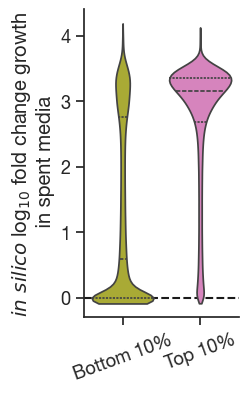

In [168]:
fig, ax = plt.subplots(figsize=(2,4))
sns.violinplot(SM_df, x = 'Category', y = 'log10 FC', inner = 'quartile', hue = 'Category', palette=palette2, cut = 0, ax = ax)
sns.despine()
plt.xlabel('')
new_labels = ['Bottom 10%', 'Top 10%']
#Rename xtick labels
ax.set_xticklabels(new_labels, rotation=20)

plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.ylabel(r'$\mathit{in\ silico}$ log$_{10}$ fold change growth'+f'\n in spent media')

plt.savefig(figure_folder / 'growth_in_spent_medium.pdf', dpi=300, bbox_inches='tight')
# plt.yscale('log')

In [169]:
SM_df['log10 Abundance'] = np.log10(SM_df['monoculture_abundance'])

Text(0, 0.5, 'Log2 FC growth in spent medium')

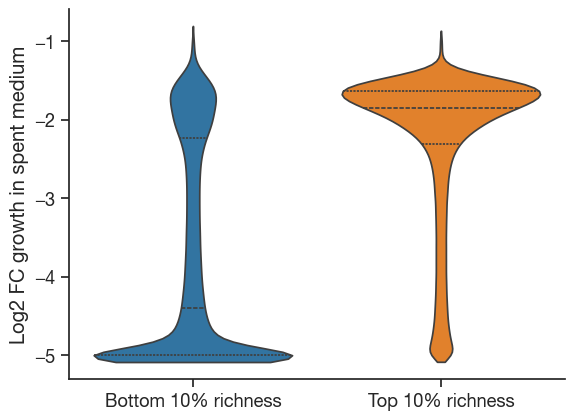

In [170]:
sns.violinplot(SM_df, x = 'Category', y = 'log10 Abundance', inner = 'quartile', hue = 'Category', palette='tab10', cut = 0)
sns.despine()
plt.xlabel('')
# plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.ylabel('Log2 FC growth in spent medium')
# plt.yscale('log')

# Interactions

## In fresh medium

In [171]:
def run_single_pair_fresh(i, j, pair, C, D, K, n_cs, leakage, max_time, initial_abundance, initial_c_conc, dt, method):
    """Run a single pair culture in fresh medium"""
    R0 = np.zeros(n_cs)
    R0[j] = initial_c_conc
    
    if C[pair, j].min() < 1e-6:
        return None
    
    l = leakage * np.ones(2)
    N0 = np.ones(2) * initial_abundance
    
    c = CRM(2, n_cs, C=C[pair, :], D=D[pair, :], dilution_rate=1e-3, l=l, K=K[pair, :])
    try:
        sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
        if sol.success:
            return {'final_abundance': c.N[-1, :], 'pair': pair, 'i': i, 'j': j}
    except (RuntimeError, ValueError):
        pass
    
    return None

pairs = list(itertools.combinations(range(4), 2))
if run_simulations:
    # Prepare parameters for parallel processing
    fresh_params = []
    for i in indices:
        n_cs = df.loc[df.i==i, 'n_cs'].values[0]
        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        
        for j in range(iterations):
            for pair in pairs:
                fresh_params.append((i, j, pair, C, D, K, n_cs, args.leakage, max_time, 
                                   initial_abundance, initial_c_conc, dt, method))
    
    # Run in parallel
    fresh_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_pair_fresh)(*params) for params in fresh_params
    )
    
    paired_fresh_culture_data = [r for r in fresh_results if r is not None]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1832777231830868s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.02175307273864746s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.02965998649597168s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done  76 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.04604005813598633s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 224 tasks      |

In [172]:
fn_inter = results_folder / f'{run}_interactions_fresh.npz'

if run_simulations:
    with open(fn_inter, 'wb') as f:
        np.savez(f, paired_fresh_culture_data)
else:
    with open(fn_inter, 'rb') as f:
        paired_fresh_culture_data = np.load(f, allow_pickle=True)['arr_0']

In [173]:
len(paired_fresh_culture_data)

675152

# In spent medium

In [174]:
def run_single_pair_spent(i, j, k_spent, pair, C, D, K, n_cs, R0, leakage, max_time, initial_abundance, dt, method):
    """Run a single pair culture in spent medium"""
    l = leakage * np.ones(2)
    N0 = np.ones(2) * initial_abundance
    
    c = CRM(2, n_cs, C=C[pair, :], D=D[pair, :], dilution_rate=1e-3, l=l, K=K[pair, :])
    try:
        sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
        if sol.success:
            return {'final_abundance': c.N[-1, :], 'pair': pair, 'i': i, 'j': j, 'spent_medium_from': k_spent}
    except (RuntimeError, ValueError):
        pass
    
    return None

all_pairs = list(itertools.combinations(range(4), 2))
if run_simulations:
    # Prepare parameters for parallel processing
    spent_params = []
    for mcdata in monoculture_data:
        i = mcdata['i']
        j = mcdata['j']
        
        if np.isnan(mcdata['final_abundance']).any() or (mcdata['final_abundance'] == initial_abundance).any():
            continue
        if mcdata['final_resources'][j] > 0.1*initial_c_conc:
            continue

        if j > 2:
            continue

        k_spent = mcdata['species_no']
        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        R0 = mcdata['final_resources'].copy()
        R0[R0 < 0] = 0
        n_cs = R0.shape[0]
        
        pairs = [p for p in all_pairs if k_spent not in p]
        for pair in pairs:
            spent_params.append((i, j, k_spent, pair, C, D, K, n_cs, R0, args.leakage, max_time, initial_abundance, dt, method))
    
    # Run in parallel
    spent_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_pair_spent)(*params) for params in spent_params
    )
    
    paired_spent_culture_data = [r for r in spent_results if r is not None]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19493718707373078s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.024765968322753906s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.08410477638244629s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.1694040298461914s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 160 tasks      

In [175]:
fn_sm_inter = results_folder / f'{run}_interactions_spent.npz'
if run_simulations:
    with open(fn_sm_inter, 'wb') as f:
        np.savez(f, paired_spent_culture_data)
else:
    with open(fn_sm_inter, 'rb') as f:
        paired_spent_culture_data = np.load(f, allow_pickle=True)['arr_0']

# Compare interactions

In [176]:
M_df = pd.DataFrame(list(monoculture_data))

In [177]:
M_df['monoculture_abundance'] = [x if np.isnan(x) else x[0] for x in M_df['final_abundance']]

In [178]:
M_df.rename(columns={'species_no':'species'}, inplace=True)

In [179]:
M_df.dropna(inplace=True)

In [180]:
# SM_df['monoculture_abundance'] = [x if np.isnan(x) else x[0] for x in SM_df['final_abundance']]
SM_df.rename(columns={'species_no':'species'}, inplace=True)

In [181]:
SM_df.dropna(inplace=True)

In [182]:
SIt_df = pd.DataFrame(list(paired_spent_culture_data))

In [183]:
SIt_df[['Species 1', 'Species 2']] = pd.DataFrame(SIt_df.pair.tolist(), index=SIt_df.index)

In [184]:
SIt_df[['Abundance 1', 'Abundance 2']] = pd.DataFrame(SIt_df.final_abundance.tolist(), index=SIt_df.index)

In [185]:
sm_ijk_to_abundance = SM_df.set_index(['i', 'j', 'spent_medium_from', 'species'])['monoculture_abundance'].to_dict()

In [186]:
SIt_df['Spent medium mono abundance 1'] = SIt_df.apply(lambda row: sm_ijk_to_abundance.get((row['i'], row['j'], row['spent_medium_from'], row['Species 1'])), axis=1)
SIt_df['Spent medium mono abundance 2'] = SIt_df.apply(lambda row: sm_ijk_to_abundance.get((row['i'], row['j'], row['spent_medium_from'], row['Species 2'])), axis=1)

In [187]:
SIt_df['Interaction 1'] = np.log10(SIt_df['Abundance 1'] / SIt_df['Spent medium mono abundance 1'])
SIt_df['Interaction 2'] = np.log10(SIt_df['Abundance 2'] / SIt_df['Spent medium mono abundance 2'])

In [188]:
SIt_df['Min mono abundance'] = SIt_df[['Spent medium mono abundance 1', 'Spent medium mono abundance 2']].min(axis=1)

In [189]:
SIt_df['Category'] = SIt_df.i.map(plot_df['Category'].to_dict())

In [190]:
SI_df = pd.melt(SIt_df, id_vars = ['i', 'j','spent_medium_from', 'pair', 'Category', 'Min mono abundance', 'Species 1', 'Species 2', 'Abundance 1', 'Abundance 2'], value_vars=['Interaction 1', 'Interaction 2'], value_name='Interaction', var_name = 'Interaction #')

In [191]:

df['Dominant species'] = df[['N1', 'N2', 'N3', 'N4']].idxmax(axis=1).str.strip('N').astype(int)
ij_to_dominant = df.set_index(['i', 'cs_j'])['Dominant species'].to_dict()

In [192]:
SI_df['Dominant'] = SI_df.apply(lambda row: ij_to_dominant[(row['i'], row['j'])], axis=1)

<Axes: ylabel='Interaction'>

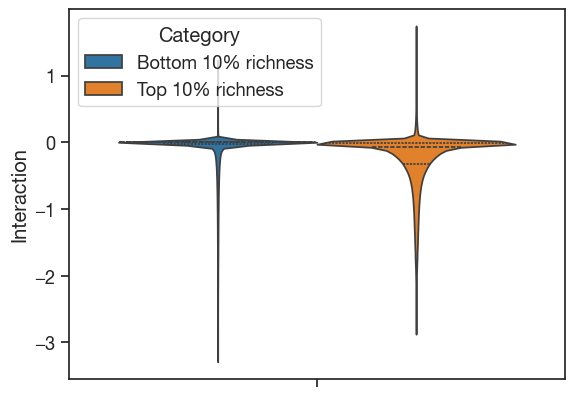

In [193]:
sns.violinplot(SI_df, y = 'Interaction', hue = 'Category', palette='tab10', cut = 0, inner = 'quartile')

In [194]:
SI_df['Min log2 FC'] = np.log2(SI_df['Min mono abundance'] / initial_abundance)

In [195]:
idx = SI_df['Min log2 FC'] > 8 #~SI_df['Min mono abundance'] > 1e-2

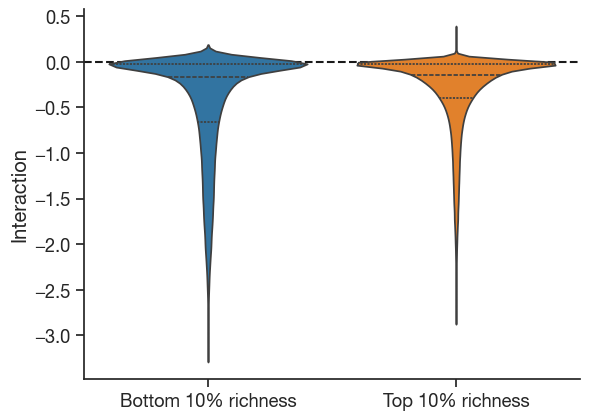

In [196]:
sns.violinplot(SI_df.loc[idx], y = 'Interaction', x = 'Category', hue = 'Category', palette='tab10', cut=0, inner = 'quartile')
plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.xlabel('')
sns.despine()

# Compare simulated and measured interactions in spent

In [197]:
measured_interactions_fn = git_folder / 'data' / '5_interactions' / 'all_interactions_cfus_with_stats.csv'
measured_df = pd.read_csv(measured_interactions_fn)

In [198]:
spent_measured = measured_df.loc[measured_df['Fresh'] == 'Spent']

In [199]:
fresh_measured = measured_df.loc[measured_df['Fresh'] != 'Spent']

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_38592/4077914673.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(SI_df.loc[SI_df['Category']=='High richness'], y = 'Interaction', c = 'k', palette='tab10', ax=ax, cut=0, legend = False, label = 'Simulated', common_norm=True)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_38592/4077914673.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(SI_df.loc[SI_df['Category']=='High richness'], y = 'Interaction', c = 'k', palette='tab10', ax=ax, cut=0, legend = False, label = 'Simulated', common_norm=True)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_38592/4077914673.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(spent_measured, y = 'log10 ratio', c = 'orange', palette='tab10', ax=ax, cut=0, legend = False, label = 'Measured')
/var

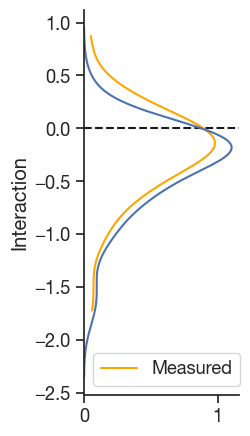

In [200]:
# sns.violinplot(SI_df.loc[SI_df['Category'] == 'High richness'], y = 'Interaction', x = 'Category', hue = 'Category', palette='tab10', cut=0, inner = 'quartile')
fig, ax = plt.subplots(figsize=(2,5))
sns.kdeplot(SI_df.loc[SI_df['Category']=='High richness'], y = 'Interaction', c = 'k', palette='tab10', ax=ax, cut=0, legend = False, label = 'Simulated', common_norm=True)
sns.kdeplot(spent_measured, y = 'log10 ratio', c = 'orange', palette='tab10', ax=ax, cut=0, legend = False, label = 'Measured')
sns.kdeplot(spent_measured.loc[spent_measured['Focal species'] != 'Ml'], y = 'log10 ratio', palette='tab10', ax=ax, common_norm=False, legend = True)
plt.legend()

plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.xlabel('')
sns.despine()

In [201]:
SI_df

,i,j,spent_medium_from,pair,Category,Min mono abundance,Species 1,Species 2,Abundance 1,Abundance 2,Interaction #,Interaction,Dominant,Min log2 FC
0,39238,0,0,"(1, 2)",Bottom 10% richness,0.006857,1,2,0.013668,0.000622,Interaction 1,-0.007063,1,9.421451
1,39238,0,0,"(1, 3)",Bottom 10% richness,0.013892,1,3,0.011160,0.004140,Interaction 1,-0.095107,1,10.440031
2,39238,0,0,"(2, 3)",Bottom 10% richness,0.006857,2,3,0.000960,0.016053,Interaction 1,-0.853972,1,9.421451
3,39238,0,2,"(0, 1)",Bottom 10% richness,0.005425,0,1,0.026668,0.000108,Interaction 1,-0.001203,1,9.083457
4,39238,0,2,"(0, 3)",Bottom 10% richness,0.023606,0,3,0.026178,0.000682,Interaction 1,-0.009248,1,11.204932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968903,75056,1,3,"(0, 2)",Top 10% richness,0.016798,0,2,0.015216,0.014769,Interaction 2,-0.183601,1,10.714103
968904,75056,1,3,"(1, 2)",Top 10% richness,0.021963,1,2,0.022041,0.013507,Interaction 2,-0.222396,1,11.100858
968905,75056,2,1,"(0, 2)",Top 10% richness,0.015176,0,2,0.020237,0.010161,Interaction 2,-0.174229,2,10.567532
968906,75056,2,1,"(0, 3)",Top 10% richness,0.017460,0,3,0.028150,0.001516,Interaction 2,-1.061432,2,10.769809


In [202]:
palette

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

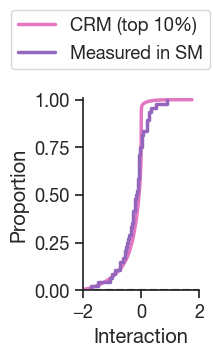

In [203]:
# sns.violinplot(SI_df.loc[SI_df['Category'] == 'High richness'], y = 'Interaction', x = 'Category', hue = 'Category', palette='tab10', cut=0, inner = 'quartile')
fig, ax = plt.subplots(figsize=(1.5,2.5))
sns.ecdfplot(SI_df.loc[SI_df['Category']=='Top 10% richness'], x = 'Interaction', c = palette[6], ax=ax, legend = False, label = 'CRM (top 10%)', lw = 2.5)
sns.ecdfplot(spent_measured, x = 'log10 ratio', c = palette[4], ax=ax, legend = False, label = 'Measured in SM', lw = 2.5)
# sns.ecdfplot(fresh_measured, x = 'log10 ratio', c = 'k', palette='tab10', ax=ax, legend = False, label = 'Measured in fresh medium', lw = 2)
plt.legend()
sns.move_legend(ax, "lower left", bbox_to_anchor=(-0.7, 1.1), title='')
ax.set_xlim(-2, 2)
ax.set_ylim(0, 1.01)
plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.xlabel('Interaction')
sns.despine()
plt.savefig(figure_folder / 'interaction_comparison.pdf', dpi=300, bbox_inches='tight')

In [204]:
SI_df.loc[idx].groupby('Category')['Interaction'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Bottom 10% richness,110202.0,-0.444707,0.586881,-3.293013,-0.659340,-0.166516,-0.022582,0.187927
Top 10% richness,322722.0,-0.313583,0.429146,-2.878256,-0.401126,-0.143084,-0.028815,0.392065


In [205]:
SI_red = SI_df.loc[idx]
SI_red = SI_red.loc[SI_red['Dominant'] == SI_red['spent_medium_from']]

<Axes: ylabel='Interaction'>

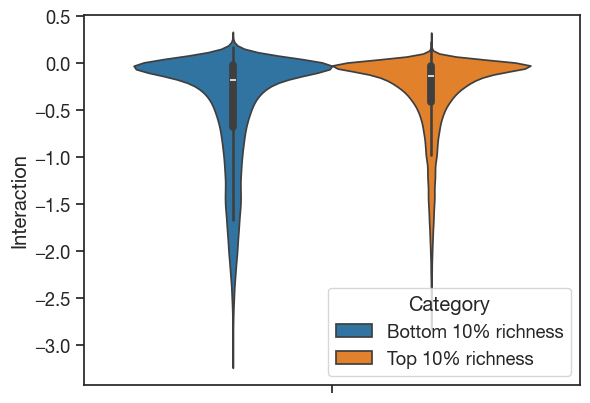

In [206]:
sns.violinplot(SI_red, y = 'Interaction', hue = 'Category', palette='tab10')


In [207]:
SI_red.groupby('Category').Interaction.describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Bottom 10% richness,19440.0,-0.458044,0.598358,-3.080170,-0.681441,-0.175475,-0.023064,0.166151
Top 10% richness,42204.0,-0.316672,0.431275,-2.729972,-0.409513,-0.143126,-0.028844,0.221799


In [208]:
# Map on i nd j to i and cs_j
richness_dict = df.set_index(['i', 'cs_j'])['richness'].to_dict()
SI_df['Richness'] = SI_df.apply(lambda row: richness_dict[(row['i'], row['j'])], axis=1)

In [209]:
# Calculate shannon diversity of monoculture abundances in spent medium
from scipy.stats import entropy
def shannon_diversity(abundances):
    abundances = np.array(abundances)
    abundances = abundances[abundances > 0]
    proportions = abundances / np.sum(abundances)
    return entropy(proportions)
df['Shannon'] = df.apply(lambda row: shannon_diversity([row['N1'], row['N2'], row['N3'], row['N4']]), axis=1)

In [210]:
shannon_dict = df.set_index(['i', 'cs_j'])['Shannon'].to_dict()
SI_df['Shannon'] = SI_df.apply(lambda row: shannon_dict[(row['i'], row['j'])], axis=1)

In [211]:
def shannon(l):
    x_tot = np.sum(l)
    p = l/x_tot
    return -np.sum([pi*np.log(pi) for pi in p])

df['Shannon 2'] = df.apply(lambda row: shannon([row['N1'], row['N2'], row['N3'], row['N4']]), axis=1)

In [212]:
df

,i,cs_j,n_cs,K_std,csp,richness,N1,N2,N3,N4,Dominant species,Shannon,Shannon 2
0,0,0,20,1.232407,0.035563,3,2.070907e-02,9.999516e-08,9.586097e-01,1.122506e-02,3,0.163346,0.163346
1,0,1,20,1.232407,0.035563,2,1.043040e-01,8.426402e-01,9.982664e-08,9.995542e-08,2,0.346828,0.346828
2,0,2,20,1.232407,0.035563,2,9.577648e-01,9.948850e-08,9.976891e-08,3.208179e-02,1,0.143029,0.143029
3,0,3,20,1.232407,0.035563,3,6.657833e-03,9.891986e-08,9.582601e-01,1.787355e-02,3,0.131359,0.131359
4,0,4,20,1.232407,0.035563,3,8.775676e-03,9.999933e-08,3.537696e-03,9.794241e-01,4,0.074277,0.074277
...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,99999,2,18,1.503493,0.059799,2,9.945381e-08,9.247700e-01,9.998896e-08,3.521938e-02,2,0.157273,0.157273
699996,99999,3,18,1.503493,0.059799,3,9.987776e-08,9.683562e-01,2.112518e-03,1.333286e-02,2,0.087061,0.087061
699997,99999,4,18,1.503493,0.059799,3,9.727905e-01,3.005265e-03,1.604868e-02,9.993910e-08,1,0.103326,0.103326
699998,99999,5,18,1.503493,0.059799,1,9.999220e-08,9.980798e-08,9.999844e-08,9.750804e-01,4,0.000005,0.000005


<Axes: ylabel='Shannon'>

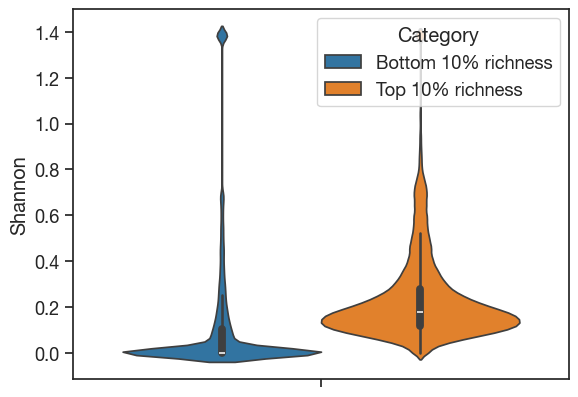

In [213]:
sns.violinplot(SI_df, y='Shannon', hue='Category', palette='tab10')

# Fresh interactions

In [214]:
FIt_df = pd.DataFrame(list(paired_fresh_culture_data))
# SIt_df = pd.DataFrame(paired_spent_culture_data)

In [215]:
FI_df = FIt_df.explode(column=['final_abundance', 'pair'])


In [216]:
FI_df.rename(columns={'pair':'species'}, inplace=True)


In [217]:
FI_df['pair'] = FI_df.index.map(FIt_df['pair'].to_dict())


In [218]:
FI_df.reset_index(drop=True, inplace=True)


In [219]:
FI_df['species'] = FI_df['species'].astype(int)

(array([  8236.,  24419.,  39826.,  44046.,  51226.,  96477., 197433.,
        125706.,  77491., 685444.]),
 array([-4.95351675e+00, -4.45816623e+00, -3.96281571e+00, -3.46746519e+00,
        -2.97211468e+00, -2.47676416e+00, -1.98141364e+00, -1.48606312e+00,
        -9.90712605e-01, -4.95362087e-01, -1.15689189e-05]),
 <BarContainer object of 10 artists>)

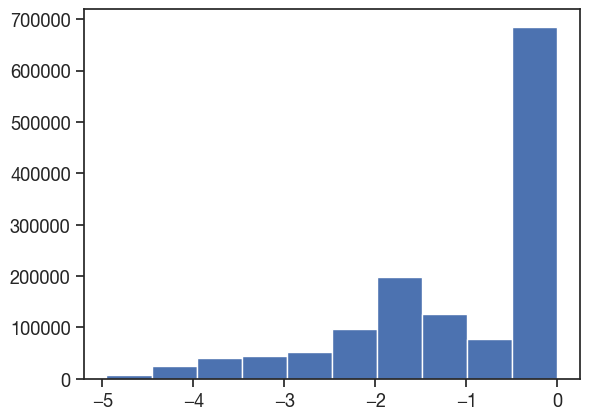

In [220]:
plt.hist(np.log10(FI_df.final_abundance.astype(float)))
# plt.xscale('log')

In [221]:
FIM_df = pd.merge(left = FI_df, right = M_df.loc[:, ['monoculture_abundance', 'i', 'j', 'species']], on=['i', 'j', 'species'], how = 'left')
# SIM_df = pd.merge(left = SI_df, right = SM_df.loc[:, ['spent_medium_from', 'species', 'i', 'j', 'monoculture_abundance', 'R0']], how = 'left')

In [222]:
FIM_df.dropna(inplace=True)
# SIM_df.dropna(inplace = True)

In [223]:
FIM_df['final_abundance'] = FIM_df['final_abundance'].astype(float)
# SIM_df['final_abundance'] = SIM_df['final_abundance'].astype(float)

In [224]:
FIM_df['log10 FC'] = np.log10(FIM_df['final_abundance'] / FIM_df['monoculture_abundance'])
# SIM_df['log10 FC'] = np.log2(SIM_df['final_abundance'] / SIM_df['monoculture_abundance'])

In [225]:
FIM_df['Category'] = FIM_df.i.map(plot_df['Category'].to_dict())
# SIM_df['Category'] = SIM_df.i.map(plot_df['Category'].to_dict())

In [226]:
FIM_df.loc[FIM_df['log10 FC'] > 0.5]

,final_abundance,species,i,j,pair,monoculture_abundance,log10 FC,Category
15,0.006193,3,39238,6,"(0, 3)",0.001769,0.544251,Bottom 10% richness
17,0.011423,3,39238,6,"(1, 3)",0.001769,0.810100,Bottom 10% richness
26,0.016982,0,28911,5,"(0, 1)",0.002328,0.863034,Bottom 10% richness
35,0.016541,3,28911,5,"(1, 3)",0.001834,0.955215,Bottom 10% richness
39,0.017344,3,28911,6,"(0, 3)",0.001875,0.966146,Bottom 10% richness
...,...,...,...,...,...,...,...,...
1350226,0.013732,1,44928,3,"(1, 3)",0.003484,0.595712,Top 10% richness
1350231,0.013839,1,44928,4,"(0, 1)",0.001915,0.858961,Top 10% richness
1350234,0.027731,1,44928,4,"(1, 2)",0.001915,1.160818,Top 10% richness
1350257,0.022825,2,75056,0,"(0, 2)",0.000681,1.525271,Top 10% richness


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_38592/4045236839.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(fresh_measured, x = 'log10 ratio', c = 'k', palette='tab10', ax=ax, legend = False, label = 'Measured in FM', lw = 2)


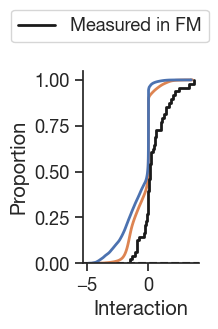

In [227]:

# sns.violinplot(SI_df.loc[SI_df['Category'] == 'High richness'], y = 'Interaction', x = 'Category', hue = 'Category', palette='tab10', cut=0, inner = 'quartile')
fig, ax = plt.subplots(figsize=(1.5,2.5))
sns.ecdfplot(FIM_df, x = 'log10 FC',hue = 'Category', ax=ax, legend = False, lw = 2)# c = palette[1]
sns.ecdfplot(fresh_measured, x = 'log10 ratio', c = 'k', palette='tab10', ax=ax, legend = False, label = 'Measured in FM', lw = 2)
# sns.ecdfplot(fresh_measured, x = 'log10 ratio', c = 'k', palette='tab10', ax=ax, legend = False, label = 'Measured in fresh medium', lw = 2)
plt.legend()
sns.move_legend(ax, "lower left", bbox_to_anchor=(-0.7, 1.1), title='')
# ax.set_xlim(-2, 2)
ax.set_ylim(0, 1.05)
plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.xlabel('Interaction')
sns.despine()
plt.savefig(figure_folder / 'interaction_comparison_fresh.pdf', dpi=300, bbox_inches='tight')